# CerebLite-MTLNet — Correct Full Multi-Task Colab Code



In [ ]:
# =========================
# 1) Libraries
# =========================
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
print("TensorFlow:", tf.__version__)
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

TensorFlow: 2.20.0


In [ ]:
# =========================
# 2) Mount Google Drive and set paths
# =========================
from google.colab import drive
drive.mount('/content/drive')

NORMAL_IMG_DIR = "/content/drive/MyDrive/Colab/PHD/few-shot/Cerebellar/data_cell_new_200/image"
NORMAL_MASK_DIR = "/content/drive/MyDrive/Colab/PHD/few-shot/Cerebellar/data_cell_new_200/ground_truth"
ABN_IMG_DIR = "/content/drive/MyDrive/Colab/PHD/few-shot/Cerebellar/Cell_Dandy/image"
ABN_MASK_DIR = "/content/drive/MyDrive/Colab/PHD/few-shot/Cerebellar/Cell_Dandy/ground-truth"

IMG_SIZE = 256
N_CHANNELS = 3
BATCH_SIZE = 8
EPOCHS = 80
LR = 1e-4
NUM_CLASSES = 2
NORMAL_LABEL = 0
ABNORMAL_LABEL = 1
AUG_FACTOR = 3

print("Normal image dir:", NORMAL_IMG_DIR)
print("Normal mask dir :", NORMAL_MASK_DIR)
print("Abn image dir   :", ABN_IMG_DIR)
print("Abn mask dir    :", ABN_MASK_DIR)

Mounted at /content/drive
Normal image dir: /content/drive/MyDrive/Colab/PHD/few-shot/Cerebellar/data_cell_new_200/image
Normal mask dir : /content/drive/MyDrive/Colab/PHD/few-shot/Cerebellar/data_cell_new_200/ground_truth
Abn image dir   : /content/drive/MyDrive/Colab/PHD/few-shot/Cerebellar/Cell_Dandy/image
Abn mask dir    : /content/drive/MyDrive/Colab/PHD/few-shot/Cerebellar/Cell_Dandy/ground-truth


In [ ]:
# =========================
# 3) Safe image-mask pairing (FIXED FOR YOUR DATASET)
# =========================
VALID_EXTS = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]

def list_files(folder):
    files = []
    for ext in VALID_EXTS:
        files.extend(glob.glob(os.path.join(folder, ext)))
    return sorted(files)

def normalize_name(path):
    name = os.path.splitext(os.path.basename(path))[0].lower().strip()

    suffixes = [
        "_g", "-g",          # YOUR DATASET
        "_mask", "-mask",
        "_gt", "-gt",
        "_label", "-label",
        "_seg", "-seg",
        "_ground_truth", "-ground_truth",
        "_groundtruth", "-groundtruth",
        "_annotation", "-annotation",
        "_json", "-json"
    ]

    changed = True
    while changed:
        changed = False
        for suffix in suffixes:
            if name.endswith(suffix):
                name = name[:-len(suffix)]
                changed = True

    return name

def make_samples(img_dir, mask_dir, class_label):
    image_paths = list_files(img_dir)
    mask_paths = list_files(mask_dir)

    mask_dict = {}

    for m in mask_paths:
        key = normalize_name(m)
        mask_dict[key] = m

    samples = []
    missing = []

    for img in image_paths:
        key = normalize_name(img)

        if key in mask_dict:
            samples.append((img, mask_dict[key], class_label))
        else:
            missing.append(img)

    print(f"Class {class_label}: images={len(image_paths)}, masks={len(mask_paths)}, paired={len(samples)}, missing={len(missing)}")

    if len(missing) > 0:
        print("Missing examples:")
        for x in missing[:10]:
            print(os.path.basename(x))

    return samples

normal_samples = make_samples(NORMAL_IMG_DIR, NORMAL_MASK_DIR, NORMAL_LABEL)
abn_samples = make_samples(ABN_IMG_DIR, ABN_MASK_DIR, ABNORMAL_LABEL)

print("Normal samples:", len(normal_samples))
print("Abnormal samples:", len(abn_samples))

Class 0: images=200, masks=200, paired=200, missing=0
Class 1: images=80, masks=80, paired=80, missing=0
Normal samples: 200
Abnormal samples: 80


In [ ]:
# =========================
# 4) Print and visualize first image-mask pairs BEFORE augmentation
# =========================
print("Normal pairs:")
for img, mask, label in normal_samples[:20]:
    print(os.path.basename(img), " ---> ", os.path.basename(mask))
print("\nAbnormal pairs:")
for img, mask, label in abn_samples[:20]:
    print(os.path.basename(img), " ---> ", os.path.basename(mask))

def read_raw_for_show(path, channels=3):
    x = tf.io.read_file(path)
    x = tf.image.decode_image(x, channels=channels, expand_animations=False)
    x = tf.image.convert_image_dtype(x, tf.float32)
    x = tf.image.resize(x, [IMG_SIZE, IMG_SIZE])
    return x.numpy()

def show_raw_pairs(samples, title, n=5):
    n = min(n, len(samples))
    plt.figure(figsize=(8, n * 3))
    for i in range(n):
        img_path, mask_path, label = samples[i]
        img = read_raw_for_show(img_path, 3)
        mask = read_raw_for_show(mask_path, 1)
        plt.subplot(n, 2, i * 2 + 1)
        plt.imshow(img); plt.title(f"{title} image | label={label}\n{os.path.basename(img_path)}"); plt.axis("off")
        plt.subplot(n, 2, i * 2 + 2)
        plt.imshow(mask[..., 0], cmap="gray"); plt.title(f"mask\n{os.path.basename(mask_path)}"); plt.axis("off")
    plt.tight_layout(); plt.show()

#show_raw_pairs(normal_samples, "Normal", n=5)
#show_raw_pairs(abn_samples, "Abnormal", n=5)

Normal pairs:
1.png  --->  1_G.png
10.png  --->  10_G.png
100.png  --->  100_G.png
101.png  --->  101_G.png
102.png  --->  102_G.png
103.png  --->  103_G.png
104.png  --->  104_G.png
105.png  --->  105_G.png
106.png  --->  106_G.png
107.png  --->  107_G.png
108.png  --->  108_G.png
109.png  --->  109_G.png
11.png  --->  11_G.png
110.png  --->  110_G.png
111.png  --->  111_G.png
112.png  --->  112_G.png
113.png  --->  113_G.png
114.png  --->  114_G.png
115.png  --->  115_G.png
116.png  --->  116_G.png

Abnormal pairs:
1.png  --->  1.png
10.png  --->  10.png
11.png  --->  11.png
12.png  --->  12.png
13.png  --->  13.png
14.png  --->  14.png
15.png  --->  15.png
16.png  --->  16.png
17.png  --->  17.png
18.png  --->  18.png
19.png  --->  19.png
2.png  --->  2.png
20.png  --->  20.png
21.png  --->  21.png
22.png  --->  22.png
23.png  --->  23.png
24.png  --->  24.png
25.png  --->  25.png
26.png  --->  26.png
27.png  --->  27.png


In [ ]:
# =========================
# 5) Split normal and abnormal separately
# =========================
def split_samples(samples, train_ratio=0.70, val_ratio=0.15, seed=42):
    rng = np.random.RandomState(seed)
    samples = np.array(samples, dtype=object)
    idx = np.arange(len(samples)); rng.shuffle(idx)
    n_train = int(len(samples) * train_ratio)
    n_val = int(len(samples) * val_ratio)
    train = [tuple(x) for x in samples[idx[:n_train]]]
    val = [tuple(x) for x in samples[idx[n_train:n_train+n_val]]]
    test = [tuple(x) for x in samples[idx[n_train+n_val:]]]
    return train, val, test

normal_train, normal_val, normal_test = split_samples(normal_samples, seed=SEED)
abn_train, abn_val, abn_test = split_samples(abn_samples, seed=SEED)
print("Before balancing:")
print("Normal train/val/test:", len(normal_train), len(normal_val), len(normal_test))
print("Abn    train/val/test:", len(abn_train), len(abn_val), len(abn_test))

Before balancing:
Normal train/val/test: 140 30 30
Abn    train/val/test: 56 12 12


In [ ]:
# =========================
# 6) Balance training set only
# =========================
def balance_two_classes(class0_samples, class1_samples, seed=42):
    rng = random.Random(seed)
    if len(class0_samples) == 0 or len(class1_samples) == 0:
        raise ValueError("One class has zero training samples.")
    if len(class0_samples) == len(class1_samples):
        return class0_samples.copy(), class1_samples.copy()
    if len(class0_samples) > len(class1_samples):
        major, minor, zero_major = class0_samples, class1_samples, True
    else:
        major, minor, zero_major = class1_samples, class0_samples, False
    repeated = []
    while len(repeated) < len(major):
        tmp = minor.copy(); rng.shuffle(tmp); repeated.extend(tmp)
    repeated = repeated[:len(major)]
    return (major.copy(), repeated) if zero_major else (repeated, major.copy())

normal_train_bal, abn_train_bal = balance_two_classes(normal_train, abn_train, seed=SEED)
train_samples = normal_train_bal + abn_train_bal
val_samples = normal_val + abn_val
test_samples = normal_test + abn_test
random.shuffle(train_samples); random.shuffle(val_samples); random.shuffle(test_samples)
print("After balancing training set:")
print("Normal train:", len(normal_train_bal))
print("Abn train   :", len(abn_train_bal))
print("Total train :", len(train_samples))
print("Validation is not oversampled:", len(val_samples))
print("Test is not oversampled:", len(test_samples))
STEPS_PER_EPOCH = max(1, (len(train_samples) * AUG_FACTOR) // BATCH_SIZE)
print("Steps per epoch:", STEPS_PER_EPOCH)

After balancing training set:
Normal train: 140
Abn train   : 140
Total train : 280
Validation is not oversampled: 42
Test is not oversampled: 42
Steps per epoch: 105


In [ ]:
# =========================
# 7) Read image, mask, edge, and build datasets
# =========================
def read_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=N_CHANNELS, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    return tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="bilinear")

def read_mask(path):
    mask = tf.io.read_file(path)
    mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
    mask = tf.image.convert_image_dtype(mask, tf.float32)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE], method="nearest")
    return tf.cast(mask > 0.5, tf.float32)

def make_edge(mask):
    max_pool = tf.nn.max_pool2d(mask[None, ...], ksize=3, strides=1, padding="SAME")[0]
    min_pool = -tf.nn.max_pool2d(-mask[None, ...], ksize=3, strides=1, padding="SAME")[0]
    return tf.clip_by_value(max_pool - min_pool, 0.0, 1.0)

def parse_sample(img_path, mask_path, label):
    image = read_image(img_path)
    mask = read_mask(mask_path)
    edge = make_edge(mask)
    label = tf.cast(label, tf.int32)
    return image, {"segmentation": mask, "edge": edge, "classification": label}

def random_zoom(image, mask, edge, min_zoom=1.0, max_zoom=1.20):
    scale = tf.random.uniform([], min_zoom, max_zoom)
    new_size = tf.cast(tf.round(tf.cast(IMG_SIZE, tf.float32) * scale), tf.int32)
    image = tf.image.resize(image, [new_size, new_size], method="bilinear")
    mask = tf.image.resize(mask, [new_size, new_size], method="nearest")
    edge = tf.image.resize(edge, [new_size, new_size], method="nearest")
    image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE, IMG_SIZE)
    mask = tf.image.resize_with_crop_or_pad(mask, IMG_SIZE, IMG_SIZE)
    edge = tf.image.resize_with_crop_or_pad(edge, IMG_SIZE, IMG_SIZE)
    return image, mask, edge

def augment_sample(image, outputs):
    mask, edge, label = outputs["segmentation"], outputs["edge"], outputs["classification"]
    if tf.random.uniform([]) > 0.5:
        image = tf.image.flip_left_right(image); mask = tf.image.flip_left_right(mask); edge = tf.image.flip_left_right(edge)
    if tf.random.uniform([]) > 0.5:
        image = tf.image.flip_up_down(image); mask = tf.image.flip_up_down(mask); edge = tf.image.flip_up_down(edge)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k); mask = tf.image.rot90(mask, k); edge = tf.image.rot90(edge, k)
    if tf.random.uniform([]) > 0.5:
        image, mask, edge = random_zoom(image, mask, edge)
    image = tf.image.random_brightness(image, max_delta=0.08)
    image = tf.image.random_contrast(image, lower=0.90, upper=1.15)
    image = tf.clip_by_value(image, 0.0, 1.0)
    mask = tf.cast(mask > 0.5, tf.float32)
    edge = make_edge(mask)
    return image, {"segmentation": mask, "edge": edge, "classification": label}

def build_dataset(samples, training=False):
    img_paths = [s[0] for s in samples]
    mask_paths = [s[1] for s in samples]
    labels = [s[2] for s in samples]
    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths, labels))
    ds = ds.map(parse_sample, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(len(samples), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.repeat()
        ds = ds.map(augment_sample, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = build_dataset(train_samples, training=True)
val_ds = build_dataset(val_samples, training=False)
test_ds = build_dataset(test_samples, training=False)
print("Datasets are ready.")

Datasets are ready.


In [ ]:
"""
# =========================
# 8) Show augmented training batch
# =========================
def show_batch(dataset, n=4):
    for images, outputs in dataset.take(1):
        masks, edges, labels = outputs["segmentation"], outputs["edge"], outputs["classification"]
        plt.figure(figsize=(12, n * 3))
        for i in range(min(n, images.shape[0])):
            plt.subplot(n, 3, i * 3 + 1); plt.imshow(images[i]); plt.title(f"Image | Label: {int(labels[i])}"); plt.axis("off")
            plt.subplot(n, 3, i * 3 + 2); plt.imshow(masks[i, ..., 0], cmap="gray"); plt.title("Mask"); plt.axis("off")
            plt.subplot(n, 3, i * 3 + 3); plt.imshow(edges[i, ..., 0], cmap="gray"); plt.title("Edge"); plt.axis("off")
        plt.tight_layout(); plt.show(); break
show_batch(train_ds, n=4)
"""

'\n# =========================\n# 8) Show augmented training batch\n# =========================\ndef show_batch(dataset, n=4):\n    for images, outputs in dataset.take(1):\n        masks, edges, labels = outputs["segmentation"], outputs["edge"], outputs["classification"]\n        plt.figure(figsize=(12, n * 3))\n        for i in range(min(n, images.shape[0])):\n            plt.subplot(n, 3, i * 3 + 1); plt.imshow(images[i]); plt.title(f"Image | Label: {int(labels[i])}"); plt.axis("off")\n            plt.subplot(n, 3, i * 3 + 2); plt.imshow(masks[i, ..., 0], cmap="gray"); plt.title("Mask"); plt.axis("off")\n            plt.subplot(n, 3, i * 3 + 3); plt.imshow(edges[i, ..., 0], cmap="gray"); plt.title("Edge"); plt.axis("off")\n        plt.tight_layout(); plt.show(); break\nshow_batch(train_ds, n=4)\n'

In [ ]:
# =========================
# 9) Metrics and losses
# =========================
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_pred = tf.sigmoid(y_pred)
    y_true = tf.cast(y_true, tf.float32)
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])
    inter = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    denom = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)
    return tf.reduce_mean((2.0 * inter + smooth) / (denom + smooth))

def jaccard_coef(y_true, y_pred, smooth=1e-6):
    y_pred = tf.sigmoid(y_pred)
    y_true = tf.cast(y_true, tf.float32)
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])
    inter = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1) - inter
    return tf.reduce_mean((inter + smooth) / (union + smooth))

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred, from_logits=True)
    return tf.reduce_mean(bce) + dice_loss(y_true, y_pred)

def focal_loss_sparse(gamma=2.0, alpha=0.75):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred, from_logits=True)
        pt = tf.exp(-ce)
        return tf.reduce_mean(alpha * tf.pow(1.0 - pt, gamma) * ce)
    return loss

In [ ]:
"""
# =========================
# 10) Lightweight multi-task network
# =========================
def dw_conv_block(x, filters, name):
    x = layers.DepthwiseConv2D(3, padding="same", use_bias=False, name=name+"_dw")(x)
    x = layers.BatchNormalization(name=name+"_dw_bn")(x)
    x = layers.Activation("relu", name=name+"_dw_relu")(x)
    x = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=name+"_pw")(x)
    x = layers.BatchNormalization(name=name+"_pw_bn")(x)
    return layers.Activation("relu", name=name+"_pw_relu")(x)

def se_block(x, ratio=8, name="se"):
    ch = int(x.shape[-1])
    s = layers.GlobalAveragePooling2D(name=name+"_gap")(x)
    s = layers.Dense(max(ch // ratio, 4), activation="relu", name=name+"_fc1")(s)
    s = layers.Dense(ch, activation="sigmoid", name=name+"_fc2")(s)
    s = layers.Reshape((1, 1, ch), name=name+"_reshape")(s)
    return layers.Multiply(name=name+"_scale")([x, s])

def attention_gate(skip, name):
    ch = int(skip.shape[-1])
    a_avg = layers.GlobalAveragePooling2D(name=name+"_gap")(skip)
    a_max = layers.GlobalMaxPooling2D(name=name+"_gmp")(skip)
    a = layers.Concatenate(name=name+"_cat")([a_avg, a_max])
    a = layers.Dense(max(ch // 4, 4), activation="relu", name=name+"_fc1")(a)
    a = layers.Dense(ch, activation="sigmoid", name=name+"_fc2")(a)
    a = layers.Reshape((1, 1, ch), name=name+"_reshape")(a)
    return layers.Multiply(name=name+"_mul")([skip, a])

def build_cereblite_mtl(input_shape=(256, 256, 3), num_classes=2):
    inp = layers.Input(input_shape, name="input_image")
    f1 = dw_conv_block(inp, 32, "enc1"); p1 = layers.MaxPooling2D(2, name="pool1")(f1)
    f2 = dw_conv_block(p1, 64, "enc2"); p2 = layers.MaxPooling2D(2, name="pool2")(f2)
    f3 = dw_conv_block(p2, 128, "enc3"); p3 = layers.MaxPooling2D(2, name="pool3")(f3)
    f4 = dw_conv_block(p3, 256, "enc4"); f4 = se_block(f4, name="bottleneck_se")
    u3 = layers.UpSampling2D(2, interpolation="bilinear", name="up3")(f4)
    u3 = layers.Concatenate(name="concat3")([u3, attention_gate(f3, "gate3")])
    d3 = dw_conv_block(u3, 128, "dec3")
    u2 = layers.UpSampling2D(2, interpolation="bilinear", name="up2")(d3)
    u2 = layers.Concatenate(name="concat2")([u2, attention_gate(f2, "gate2")])
    d2 = dw_conv_block(u2, 64, "dec2")
    u1 = layers.UpSampling2D(2, interpolation="bilinear", name="up1")(d2)
    u1 = layers.Concatenate(name="concat1")([u1, attention_gate(f1, "gate1")])
    d1 = dw_conv_block(u1, 32, "dec1")
    segmentation = layers.Conv2D(1, 1, padding="same", name="segmentation")(d1)
    edge = layers.Conv2D(1, 1, padding="same", name="edge")(d1)
    mask_prob = layers.Activation("sigmoid", name="mask_prob_for_cls")(segmentation)
    mask_small = layers.Resizing(32, 32, interpolation="bilinear", name="mask_resize_for_cls")(mask_prob)
    guided = layers.Multiply(name="mask_guided_feature")([f4, mask_small])
    guided = se_block(guided, name="cls_se")
    cls = layers.GlobalAveragePooling2D(name="cls_gap")(guided)
    cls = layers.Dropout(0.30, name="cls_dropout")(cls)
    cls = layers.Dense(128, activation="relu", name="cls_fc1")(cls)
    classification = layers.Dense(num_classes, name="classification")(cls)
    return models.Model(inp, {"segmentation": segmentation, "edge": edge, "classification": classification}, name="CerebLite_MTLNet")

model = build_cereblite_mtl((IMG_SIZE, IMG_SIZE, N_CHANNELS), NUM_CLASSES)
#model.summary()
"""

In [ ]:
# =========================
# 10) Novel lightweight multi-task network
# DWMamba-KANet-Lite
# =========================

import tensorflow as tf
from tensorflow.keras import layers, models

# ---------- basic layers ----------
def norm_act(x, name):
    x = layers.BatchNormalization(name=name+"_bn")(x)
    return layers.Activation("gelu", name=name+"_gelu")(x)

def patch_stem(x, filters, name):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=name+"_conv1")(x)
    x = norm_act(x, name+"_1")
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=name+"_conv2")(x)
    x = norm_act(x, name+"_2")
    return x

# ---------- Lite Mamba / SSM-inspired block ----------
def lite_ssm_block(x, filters, name):
    shortcut = x

    x = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=name+"_in_proj")(x)
    x = norm_act(x, name+"_in")

    # horizontal selective scan approximation
    h = layers.DepthwiseConv2D((1, 7), padding="same", use_bias=False, name=name+"_h_scan")(x)

    # vertical selective scan approximation
    v = layers.DepthwiseConv2D((7, 1), padding="same", use_bias=False, name=name+"_v_scan")(x)

    # local morphology branch
    l = layers.DepthwiseConv2D(3, padding="same", dilation_rate=2, use_bias=False, name=name+"_local_dilated")(x)

    # selective gate
    gate = layers.Conv2D(filters, 1, padding="same", activation="sigmoid", name=name+"_selective_gate")(x)

    y = layers.Add(name=name+"_scan_sum")([h, v, l])
    y = layers.Multiply(name=name+"_selective_multiply")([y, gate])
    y = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=name+"_out_proj")(y)
    y = layers.BatchNormalization(name=name+"_out_bn")(y)

    if int(shortcut.shape[-1]) != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=name+"_shortcut")(shortcut)
        shortcut = layers.BatchNormalization(name=name+"_shortcut_bn")(shortcut)

    y = layers.Add(name=name+"_residual")([shortcut, y])
    return layers.Activation("gelu", name=name+"_out")(y)

# ---------- KAN-like nonlinear feature mixer ----------
def kan_mixer(x, filters, name):
    shortcut = x

    # parallel nonlinear basis transformations
    b1 = layers.Conv2D(filters, 1, padding="same", activation="gelu", name=name+"_basis_gelu")(x)
    b2 = layers.Conv2D(filters, 1, padding="same", activation="tanh", name=name+"_basis_tanh")(x)
    b3 = layers.Conv2D(filters, 1, padding="same", activation="sigmoid", name=name+"_basis_sigmoid")(x)

    y = layers.Concatenate(name=name+"_basis_concat")([b1, b2, b3])
    y = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=name+"_basis_fusion")(y)
    y = layers.BatchNormalization(name=name+"_bn")(y)

    if int(shortcut.shape[-1]) != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=name+"_shortcut")(shortcut)
        shortcut = layers.BatchNormalization(name=name+"_shortcut_bn")(shortcut)

    y = layers.Add(name=name+"_residual")([shortcut, y])
    return layers.Activation("gelu", name=name+"_out")(y)

# ---------- prompt-guided skip fusion ----------
def prompt_guided_fusion(dec, skip, prompt, filters, name):
    prompt_r = layers.Resizing(
        int(skip.shape[1]),
        int(skip.shape[2]),
        interpolation="bilinear",
        name=name+"_prompt_resize"
    )(prompt)

    prompt_gate = layers.Conv2D(
        int(skip.shape[-1]),
        1,
        padding="same",
        activation="sigmoid",
        name=name+"_prompt_gate"
    )(prompt_r)

    skip = layers.Multiply(name=name+"_skip_prompted")([skip, prompt_gate])

    x = layers.Concatenate(name=name+"_concat")([dec, skip])
    x = lite_ssm_block(x, filters, name=name+"_ssm")
    x = kan_mixer(x, filters, name=name+"_kan")
    return x

# ---------- morphology descriptor ----------
def morphology_descriptor(mask, name):
    area = layers.GlobalAveragePooling2D(name=name+"_area")(mask)

    sobel_x = np.array(
        [[-1, 0, 1],
         [-2, 0, 2],
         [-1, 0, 1]],
        dtype=np.float32
    ).reshape((3, 3, 1, 1))

    sobel_y = np.array(
        [[-1, -2, -1],
         [ 0,  0,  0],
         [ 1,  2,  1]],
        dtype=np.float32
    ).reshape((3, 3, 1, 1))

    dx = layers.Conv2D(
        1, 3, padding="same", use_bias=False, trainable=False,
        kernel_initializer=tf.keras.initializers.Constant(sobel_x),
        name=name+"_sobel_x"
    )(mask)

    dy = layers.Conv2D(
        1, 3, padding="same", use_bias=False, trainable=False,
        kernel_initializer=tf.keras.initializers.Constant(sobel_y),
        name=name+"_sobel_y"
    )(mask)

    edge_mag = layers.Add(name=name+"_edge_add")([
        layers.Lambda(lambda z: tf.abs(z), name=name+"_abs_x")(dx),
        layers.Lambda(lambda z: tf.abs(z), name=name+"_abs_y")(dy)
    ])

    perimeter = layers.GlobalAveragePooling2D(name=name+"_perimeter")(edge_mag)

    desc = layers.Concatenate(name=name+"_shape_descriptor")([area, perimeter])
    return desc

# ---------- full model ----------
def build_dwmamba_kanet_lite(input_shape=(256, 256, 3), num_classes=2):
    inp = layers.Input(input_shape, name="input_fetal_ultrasound")

    # local anatomical texture stem
    x0 = patch_stem(inp, 24, "local_texture_stem")

    # encoder
    f1 = lite_ssm_block(x0, 32, "enc1_mamba")
    f1 = kan_mixer(f1, 32, "enc1_kan")
    p1 = layers.Conv2D(48, 3, strides=2, padding="same", name="down1")(f1)

    f2 = lite_ssm_block(p1, 64, "enc2_mamba")
    f2 = kan_mixer(f2, 64, "enc2_kan")
    p2 = layers.Conv2D(96, 3, strides=2, padding="same", name="down2")(f2)

    f3 = lite_ssm_block(p2, 128, "enc3_mamba")
    f3 = kan_mixer(f3, 128, "enc3_kan")
    p3 = layers.Conv2D(160, 3, strides=2, padding="same", name="down3")(f3)

    f4 = lite_ssm_block(p3, 192, "bottleneck_mamba")
    f4 = kan_mixer(f4, 192, "bottleneck_kan")

    # auto anatomical prompt
    prompt = layers.Conv2D(1, 1, padding="same", activation="sigmoid", name="auto_cerebellum_prompt")(f4)

    # decoder
    u3 = layers.UpSampling2D(2, interpolation="bilinear", name="up3")(f4)
    d3 = prompt_guided_fusion(u3, f3, prompt, 128, "decoder3_prompt_fusion")

    u2 = layers.UpSampling2D(2, interpolation="bilinear", name="up2")(d3)
    d2 = prompt_guided_fusion(u2, f2, prompt, 64, "decoder2_prompt_fusion")

    u1 = layers.UpSampling2D(2, interpolation="bilinear", name="up1")(d2)
    d1 = prompt_guided_fusion(u1, f1, prompt, 32, "decoder1_prompt_fusion")

    # outputs
    segmentation = layers.Conv2D(1, 1, padding="same", name="segmentation")(d1)
    edge = layers.Conv2D(1, 1, padding="same", name="edge")(d1)

    # mask-guided classification
    mask_prob = layers.Activation("sigmoid", name="mask_prob_for_cls")(segmentation)
    mask_small = layers.Resizing(32, 32, interpolation="bilinear", name="mask_resize_for_cls")(mask_prob)

    guided_feature = layers.Multiply(name="mask_guided_bottleneck")([f4, mask_small])
    guided_feature = lite_ssm_block(guided_feature, 192, "cls_mamba")
    guided_feature = kan_mixer(guided_feature, 192, "cls_kan")

    deep_feat = layers.GlobalAveragePooling2D(name="cls_global_feature")(guided_feature)
    shape_feat = morphology_descriptor(mask_prob, "morphology_branch")

    cls = layers.Concatenate(name="deep_shape_fusion")([deep_feat, shape_feat])
    cls = layers.Dense(128, activation="gelu", name="cls_dense1")(cls)
    cls = layers.Dropout(0.35, name="cls_dropout")(cls)
    classification = layers.Dense(num_classes, name="classification")(cls)

    model = models.Model(
        inp,
        {
            "segmentation": segmentation,
            "edge": edge,
            "classification": classification
        },
        name="DWMamba_KANet_Lite"
    )

    return model

model = build_dwmamba_kanet_lite(
    input_shape=(IMG_SIZE, IMG_SIZE, N_CHANNELS),
    num_classes=NUM_CLASSES
)

model.summary()

Model: "DWMamba_KANet_Lite"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_fetal_ultras… │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_texture_stem… │ (None, 256, 256,  │        648 │ input_fetal_ultr… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_texture_stem… │ (None, 256, 256,  │         96 │ local_texture_st… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_texture_stem… │ (None, 256, 256,  │          0 │ local_texture_st… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_texture_stem… │ (None, 256, 256,  │      5,184 │ local_texture_st… │
│ (Conv2D)            │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_texture_stem… │ (None, 256, 256,  │         96 │ local_texture_st… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_texture_stem… │ (None, 256, 256,  │          0 │ local_texture_st… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_mamba_in_proj  │ (None, 256, 256,  │        768 │ local_texture_st… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_mamba_in_bn    │ (None, 256, 256,  │        128 │ enc1_mamba_in_pr… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_mamba_in_gelu  │ (None, 256, 256,  │          0 │ enc1_mamba_in_bn… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_mamba_h_scan   │ (None, 256, 256,  │        224 │ enc1_mamba_in_ge… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_mamba_v_scan   │ (None, 256, 256,  │        224 │ enc1_mamba_in_ge… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_mamba_local_d… │ (None, 256, 256,  │        288 │ enc1_mamba_in_ge… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_mamba_scan_sum │ (None, 256, 256,  │          0 │ enc1_mamba_h_sca… │
│ (Add)               │ 32)               │            │ enc1_mamba_v_sca… │
│                     │                   │            │ enc1_mamba_local… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_mamba_selecti… │ (None, 256, 256,  │      1,056 │ enc1_mamba_in_ge… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_mamba_selecti… │ (None, 256, 256,  │          0 │ enc1_mamba_scan_… │
│ (Multiply)          │ 32)               │            │ enc1_mamba_selec… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,497,807 (5.71 MB)

 Trainable params: 1,491,421 (5.69 MB)

 Non-trainable params: 6,386 (24.95 KB)

In [ ]:
# =========================
# 11) Compile and train
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss={"segmentation": bce_dice_loss, "edge": bce_dice_loss, "classification": focal_loss_sparse(gamma=2.0, alpha=0.75)},
    loss_weights={"segmentation": 0.50, "edge": 0.20, "classification": 0.30},
    metrics={"segmentation": [dice_coef, jaccard_coef], "classification": [tf.keras.metrics.SparseCategoricalAccuracy(name="acc")]}
)
SAVE_PATH = "/content/drive/MyDrive/Colab/PHD/multi-task/best_cereblite_mtl.keras"
callbacks = [
    ModelCheckpoint(SAVE_PATH, monitor="val_segmentation_dice_coef", mode="max", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor="val_loss", patience=18, restore_best_weights=True, verbose=1)
]
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, steps_per_epoch=STEPS_PER_EPOCH, callbacks=callbacks)

Epoch 1/80
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 928ms/step - classification_acc: 0.5521 - classification_loss: 0.1608 - edge_loss: 1.9411 - loss: 1.1165 - segmentation_dice_coef: 0.0899 - segmentation_jaccard_coef: 0.0475 - segmentation_loss: 1.3600
Epoch 1: val_segmentation_dice_coef improved from None to 0.06821, saving model to /content/drive/MyDrive/Colab/PHD/multi-task/best_cereblite_mtl.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab/PHD/multi-task/best_cereblite_mtl.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - classification_acc: 0.6405 - classification_loss: 0.1268 - edge_loss: 1.6119 - loss: 0.9768 - segmentation_dice_coef: 0.0972 - segmentation_jaccard_coef: 0.0515 - segmentation_loss: 1.2328 - val_classification_acc: 0.7143 - val_classification_loss: 0.1212 - val_edge_loss: 1.4709 - val_loss: 1.0562 - val_segmentation_dice_coef: 0.0682 - val_segmentation_jaccard_coef: 0.0354 - val_segmentation_loss: 1.4530 - learning_rate: 1.0000e-04
Epoch 2/80
105/105 

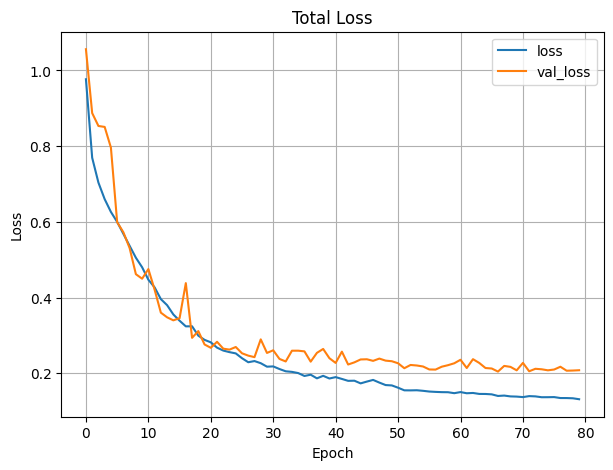

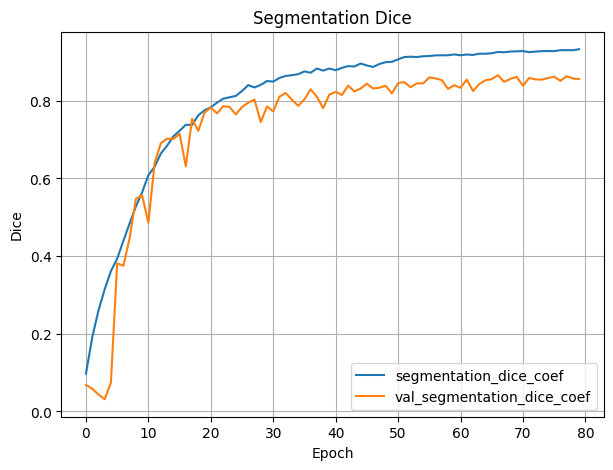

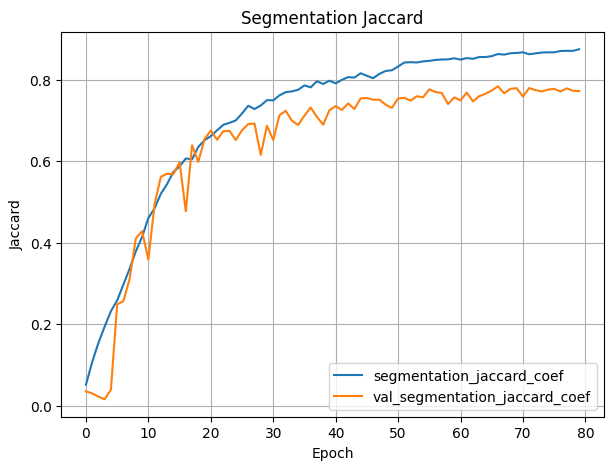

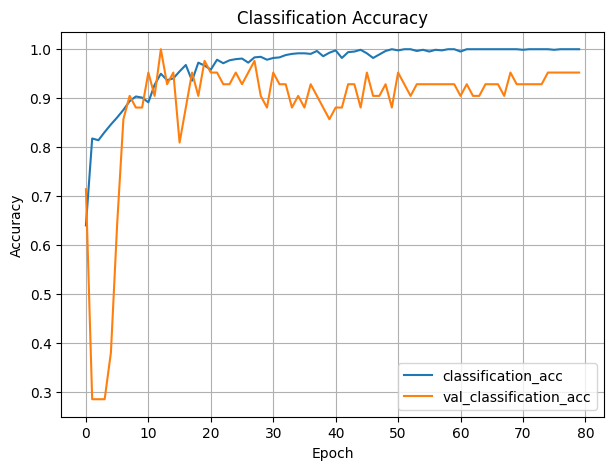

In [ ]:
# =========================
# 12) Training diagrams
# =========================
def plot_history(history):
    hist = history.history
    def safe_plot(keys, title, ylabel):
        plt.figure(figsize=(7, 5))
        for key in keys:
            if key in hist: plt.plot(hist[key], label=key)
        plt.title(title); plt.xlabel("Epoch"); plt.ylabel(ylabel); plt.legend(); plt.grid(True); plt.show()
    safe_plot(["loss", "val_loss"], "Total Loss", "Loss")
    safe_plot(["segmentation_dice_coef", "val_segmentation_dice_coef"], "Segmentation Dice", "Dice")
    safe_plot(["segmentation_jaccard_coef", "val_segmentation_jaccard_coef"], "Segmentation Jaccard", "Jaccard")
    safe_plot(["classification_acc", "val_classification_acc"], "Classification Accuracy", "Accuracy")
plot_history(history)

In [ ]:
# =========================
# 13) Load best model and evaluate
# =========================

# rebuild architecture
best_model = build_dwmamba_kanet_lite(
    input_shape=(IMG_SIZE, IMG_SIZE, N_CHANNELS),
    num_classes=NUM_CLASSES
)

# compile
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss={
        "segmentation": bce_dice_loss,
        "edge": bce_dice_loss,
        "classification": focal_loss_sparse(gamma=2.0, alpha=0.75)
    },
    loss_weights={
        "segmentation": 0.50,
        "edge": 0.20,
        "classification": 0.30
    },
    metrics={
        "segmentation": [dice_coef, jaccard_coef],
        "classification": [
            tf.keras.metrics.SparseCategoricalAccuracy(name="acc")
        ]
    }
)



# evaluate
keras_results = best_model.evaluate(test_ds, verbose=1)
print("\nEvaluation results:")
print(keras_results)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 420 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best model loaded successfully.
6/6 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - classification_acc: 1.0000 - classification_loss: 0.0045 - edge_loss: 0.5195 - loss: 0.1882 - segmentation_dice_coef: 0.8717 - segmentation_jaccard_coef: 0.7863 - segmentation_loss: 0.1678   

Evaluation results:
[0.18824028968811035, 0.16781096160411835, 0.5195282101631165, 0.004498351830989122, 1.0, 0.8716826438903809, 0.786260187625885]


In [ ]:

keras_results = model.evaluate(test_ds, verbose=1)
print(keras_results)

6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - classification_acc: 1.0000 - classification_loss: 0.0045 - edge_loss: 0.5195 - loss: 0.1882 - segmentation_dice_coef: 0.8717 - segmentation_jaccard_coef: 0.7863 - segmentation_loss: 0.1678   
[0.18824028968811035, 0.16781096160411835, 0.5195282101631165, 0.004498351830989122, 1.0, 0.8716826438903809, 0.786260187625885]


In [ ]:
# =========================
# 14) Final manual test metrics
# =========================
def numpy_dice(y_true, y_pred, smooth=1e-6):
    y_true = y_true.astype(np.float32).reshape(y_true.shape[0], -1)
    y_pred = y_pred.astype(np.float32).reshape(y_pred.shape[0], -1)
    inter = np.sum(y_true * y_pred, axis=1)
    denom = np.sum(y_true, axis=1) + np.sum(y_pred, axis=1)
    return np.mean((2 * inter + smooth) / (denom + smooth))

def numpy_jaccard(y_true, y_pred, smooth=1e-6):
    y_true = y_true.astype(np.float32).reshape(y_true.shape[0], -1)
    y_pred = y_pred.astype(np.float32).reshape(y_pred.shape[0], -1)
    inter = np.sum(y_true * y_pred, axis=1)
    union = np.sum(y_true, axis=1) + np.sum(y_pred, axis=1) - inter
    return np.mean((inter + smooth) / (union + smooth))

all_true_masks, all_pred_masks, all_true_labels, all_pred_labels = [], [], [], []
for images, outputs in test_ds:
    preds = model.predict(images, verbose=0)
    pred_mask_bin = (tf.sigmoid(preds["segmentation"]).numpy() > 0.5).astype(np.float32)
    true_mask = outputs["segmentation"].numpy().astype(np.float32)
    cls_pred = np.argmax(preds["classification"], axis=1)
    all_true_masks.append(true_mask); all_pred_masks.append(pred_mask_bin)
    all_true_labels.extend(outputs["classification"].numpy().tolist())
    all_pred_labels.extend(cls_pred.tolist())
all_true_masks = np.concatenate(all_true_masks, axis=0)
all_pred_masks = np.concatenate(all_pred_masks, axis=0)
all_true_labels = np.array(all_true_labels); all_pred_labels = np.array(all_pred_labels)
print("========== Final Test Results ==========")
print(f"Segmentation Dice     : {numpy_dice(all_true_masks, all_pred_masks):.4f}")
print(f"Segmentation Jaccard  : {numpy_jaccard(all_true_masks, all_pred_masks):.4f}")
print(f"Classification ACC    : {accuracy_score(all_true_labels, all_pred_labels):.4f}")
print(f"Classification Recall : {recall_score(all_true_labels, all_pred_labels, zero_division=0):.4f}")
print(f"Classification Prec.  : {precision_score(all_true_labels, all_pred_labels, zero_division=0):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(all_true_labels, all_pred_labels))
print("\nClassification Report:")
print(classification_report(all_true_labels, all_pred_labels, target_names=["Normal", "DWM/Abnormal"], zero_division=0))

========== Final Test Results ==========
Segmentation Dice     : 0.8774
Segmentation Jaccard  : 0.7971
Classification ACC    : 1.0000
Classification Recall : 1.0000
Classification Prec.  : 1.0000

Confusion Matrix:
[[30  0]
 [ 0 12]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        30
DWM/Abnormal       1.00      1.00      1.00        12

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



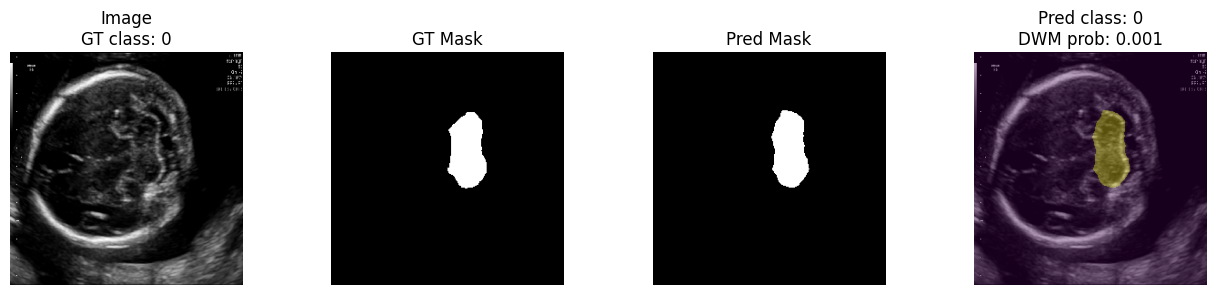

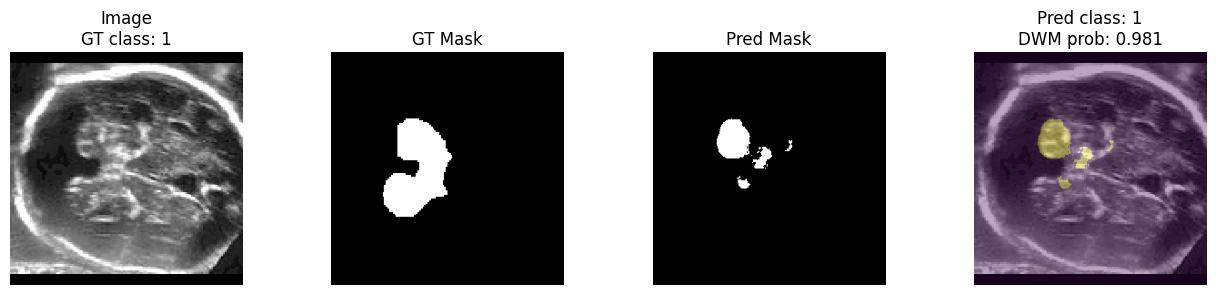

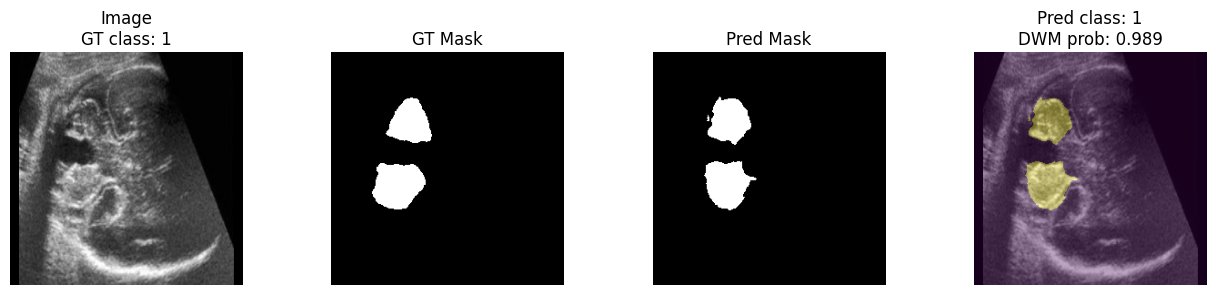

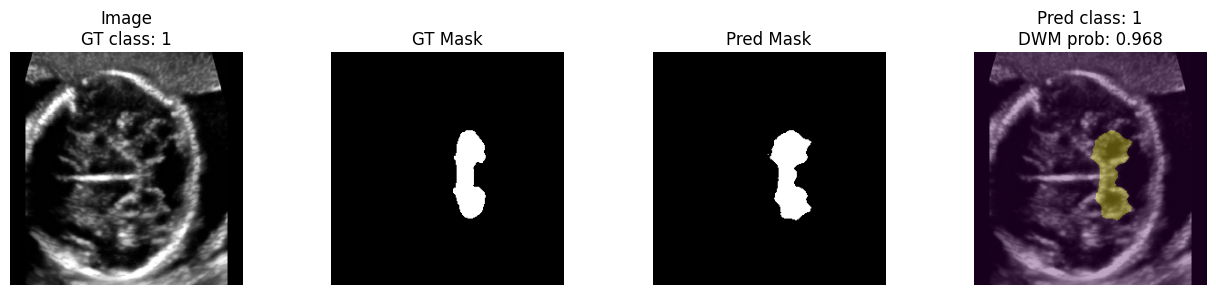

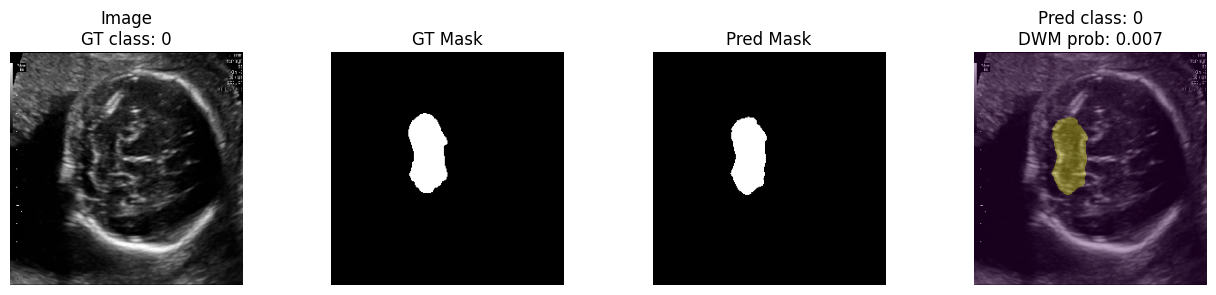

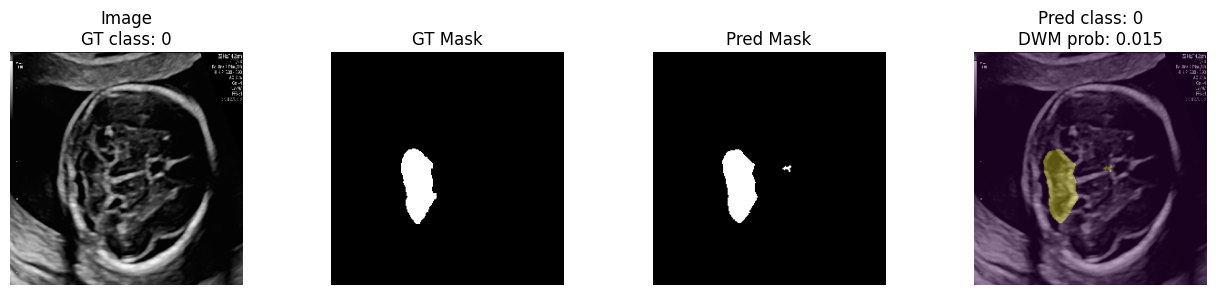

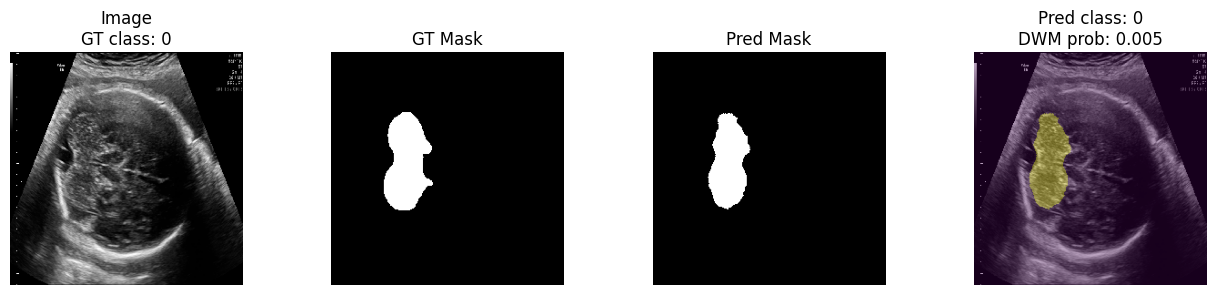

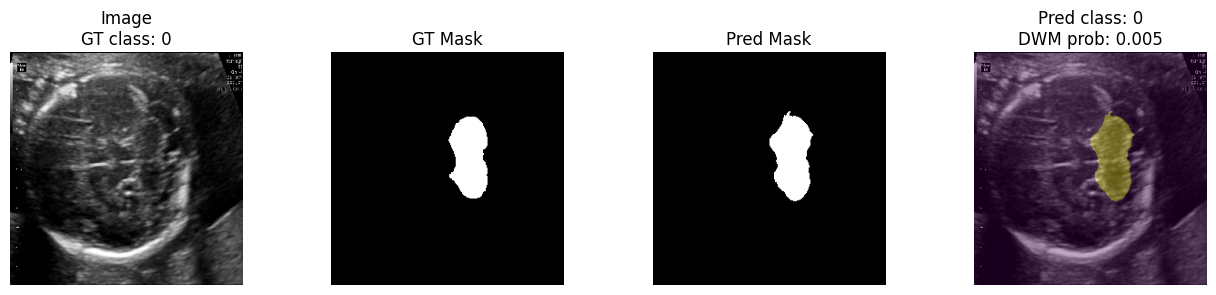

In [ ]:
# =========================
# 15) Visualize predictions
# =========================
def show_predictions(dataset, model, n=8):
    shown = 0
    for images, outputs in dataset:
        preds = model.predict(images, verbose=0)
        pred_masks_bin = (tf.sigmoid(preds["segmentation"]).numpy() > 0.5).astype(np.float32)
        cls_probs = tf.nn.softmax(preds["classification"], axis=1).numpy()
        cls_pred = np.argmax(cls_probs, axis=1)
        true_masks = outputs["segmentation"].numpy(); true_labels = outputs["classification"].numpy()
        for i in range(images.shape[0]):
            if shown >= n: return
            plt.figure(figsize=(13, 3))
            plt.subplot(1, 4, 1); plt.imshow(images[i]); plt.title(f"Image\nGT class: {true_labels[i]}"); plt.axis("off")
            plt.subplot(1, 4, 2); plt.imshow(true_masks[i, ..., 0], cmap="gray"); plt.title("GT Mask"); plt.axis("off")
            plt.subplot(1, 4, 3); plt.imshow(pred_masks_bin[i, ..., 0], cmap="gray"); plt.title("Pred Mask"); plt.axis("off")
            plt.subplot(1, 4, 4); plt.imshow(images[i]); plt.imshow(pred_masks_bin[i, ..., 0], alpha=0.35); plt.title(f"Pred class: {cls_pred[i]}\nDWM prob: {cls_probs[i, 1]:.3f}"); plt.axis("off")
            plt.tight_layout(); plt.show(); shown += 1
show_predictions(test_ds, best_model, n=8)

In [ ]:
# =========================
# 16) Save final model to Google Drive
# =========================
FINAL_MODEL_PATH = "/content/drive/MyDrive/Colab/PHD/multi-task/best_cereblite_mtl_final.keras"
best_model.save(FINAL_MODEL_PATH)
print("Model saved to:")
print(FINAL_MODEL_PATH)

Model saved to:
/content/drive/MyDrive/Colab/PHD/multi-task/best_cereblite_mtl_final.keras


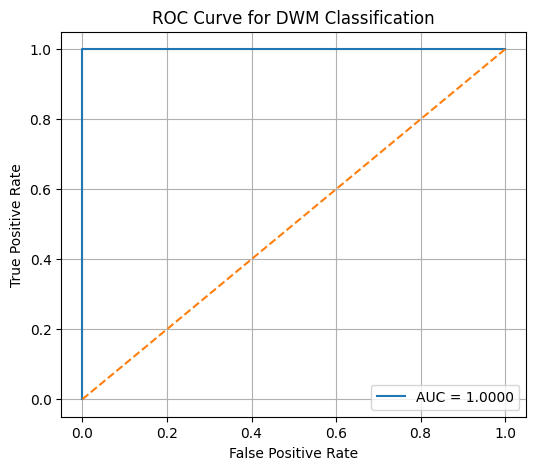

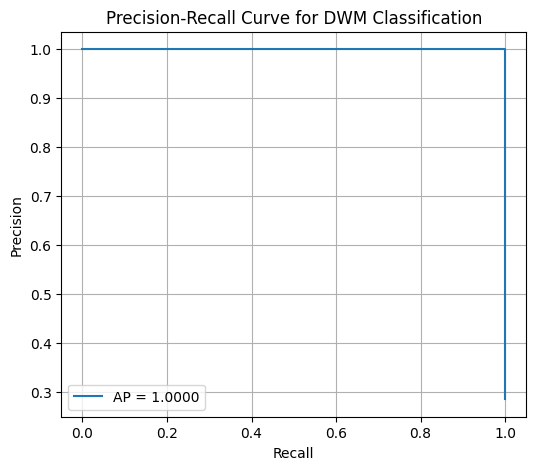

ROC-AUC: 1.0000
Average Precision: 1.0000


In [ ]:
# =========================
# ROC Curve + Precision-Recall Curve for Classification
# =========================
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

y_true = []
y_score = []

for images, outputs in test_ds:
    preds = best_model.predict(images, verbose=0)

    logits = preds["classification"]
    probs = tf.nn.softmax(logits, axis=1).numpy()

    y_true.extend(outputs["classification"].numpy())
    y_score.extend(probs[:, 1])  # probability of DWM / abnormal class

y_true = np.array(y_true)
y_score = np.array(y_score)

# ROC
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for DWM Classification")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for DWM Classification")
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Average Precision: {ap:.4f}")

In [ ]:
# =========================
# Segmentation analysis figures
# Dice / Jaccard distribution + examples
# =========================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def dice_single(y_true, y_pred, smooth=1e-6):
    y_true = y_true.reshape(-1).astype(np.float32)
    y_pred = y_pred.reshape(-1).astype(np.float32)
    inter = np.sum(y_true * y_pred)
    return (2 * inter + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)

def jaccard_single(y_true, y_pred, smooth=1e-6):
    y_true = y_true.reshape(-1).astype(np.float32)
    y_pred = y_pred.reshape(-1).astype(np.float32)
    inter = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - inter
    return (inter + smooth) / (union + smooth)

images_list = []
gt_masks_list = []
pred_masks_list = []
dice_scores = []
jaccard_scores = []

for images, outputs in test_ds:
    preds = best_model.predict(images, verbose=0)

    pred_masks = tf.sigmoid(preds["segmentation"]).numpy()
    pred_masks_bin = (pred_masks > 0.5).astype(np.float32)

    gt_masks = outputs["segmentation"].numpy()

    for i in range(images.shape[0]):
        d = dice_single(gt_masks[i], pred_masks_bin[i])
        j = jaccard_single(gt_masks[i], pred_masks_bin[i])

        images_list.append(images[i].numpy())
        gt_masks_list.append(gt_masks[i])
        pred_masks_list.append(pred_masks_bin[i])
        dice_scores.append(d)
        jaccard_scores.append(j)

dice_scores = np.array(dice_scores)
jaccard_scores = np.array(jaccard_scores)

print(f"Mean Dice: {dice_scores.mean():.4f} ± {dice_scores.std():.4f}")
print(f"Mean Jaccard: {jaccard_scores.mean():.4f} ± {jaccard_scores.std():.4f}")

Mean Dice: 0.8774 ± 0.1136
Mean Jaccard: 0.7971 ± 0.1536


/tmp/ipykernel_5722/3656212916.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dice_scores, jaccard_scores], labels=["Dice", "Jaccard"])


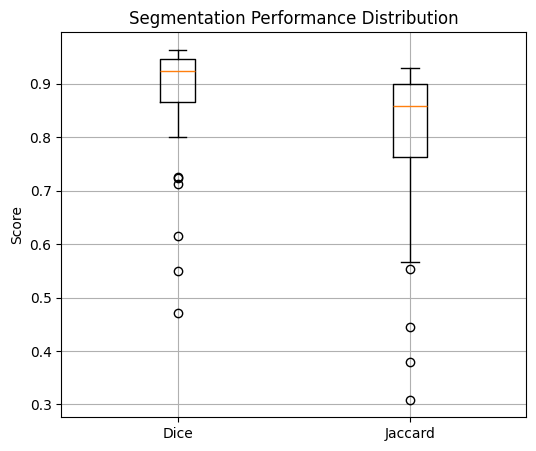

In [ ]:
plt.figure(figsize=(6, 5))
plt.boxplot([dice_scores, jaccard_scores], labels=["Dice", "Jaccard"])
plt.ylabel("Score")
plt.title("Segmentation Performance Distribution")
plt.grid(True)
plt.show()

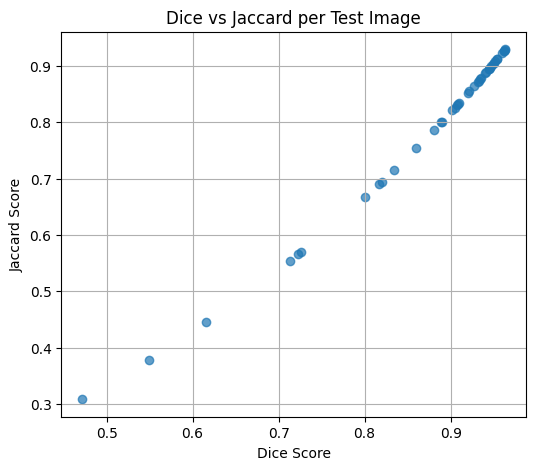

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(dice_scores, jaccard_scores, alpha=0.7)
plt.xlabel("Dice Score")
plt.ylabel("Jaccard Score")
plt.title("Dice vs Jaccard per Test Image")
plt.grid(True)
plt.show()

/tmp/ipykernel_5722/1031504799.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


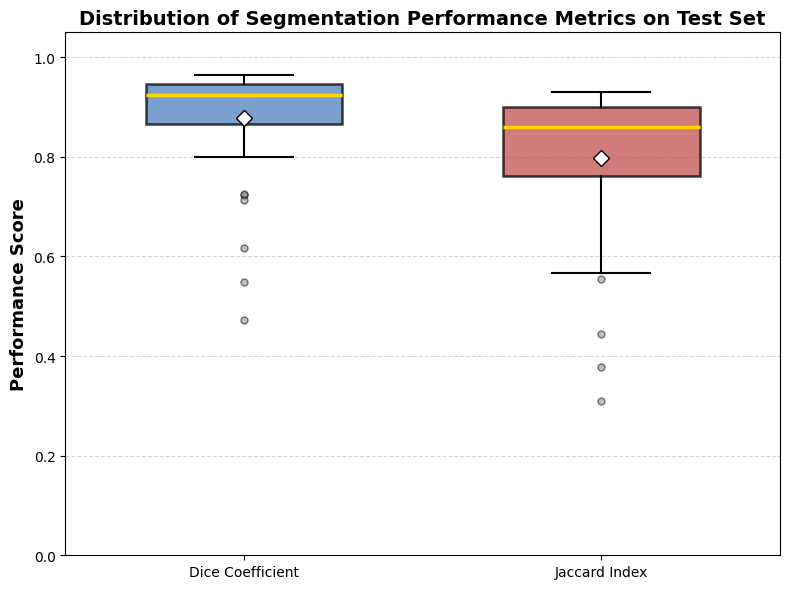

In [ ]:
# Professional segmentation performance boxplot
plt.figure(figsize=(8, 6))

box = plt.boxplot(
    [dice_scores, jaccard_scores],
    labels=["Dice Coefficient", "Jaccard Index"],
    patch_artist=True,
    widths=0.55,
    showmeans=True,
    meanline=False
)

# colors
colors = ["#4F81BD", "#C0504D"]  # blue, red

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor("black")
    patch.set_linewidth(1.8)

for whisker in box["whiskers"]:
    whisker.set(color="black", linewidth=1.5)

for cap in box["caps"]:
    cap.set(color="black", linewidth=1.5)

for median in box["medians"]:
    median.set(color="gold", linewidth=2.5)

for mean in box["means"]:
    mean.set(
        marker="D",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=8
    )

for flier in box["fliers"]:
    flier.set(
        marker="o",
        markerfacecolor="gray",
        alpha=0.5,
        markersize=5
    )

plt.ylabel("Performance Score", fontsize=13, fontweight="bold")
plt.title(
    "Distribution of Segmentation Performance Metrics on Test Set",
    fontsize=14,
    fontweight="bold"
)

plt.ylim(0, 1.05)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

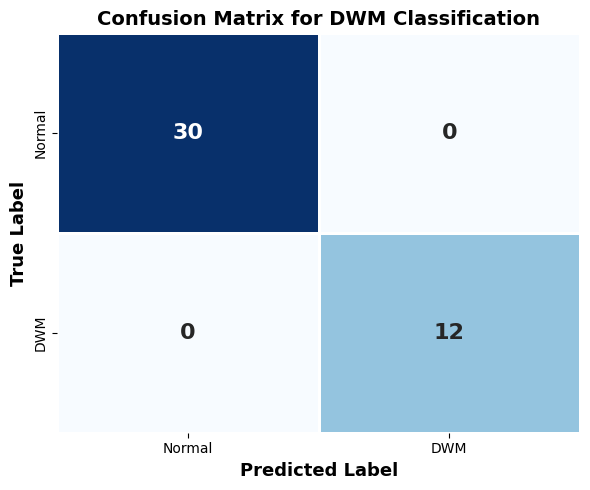

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (y_score >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "DWM"],
    yticklabels=["Normal", "DWM"],
    cbar=False,
    linewidths=1,
    linecolor="white",
    annot_kws={"size": 16, "weight": "bold"}
)

plt.xlabel("Predicted Label", fontsize=13, fontweight="bold")
plt.ylabel("True Label", fontsize=13, fontweight="bold")
plt.title("Confusion Matrix for DWM Classification", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

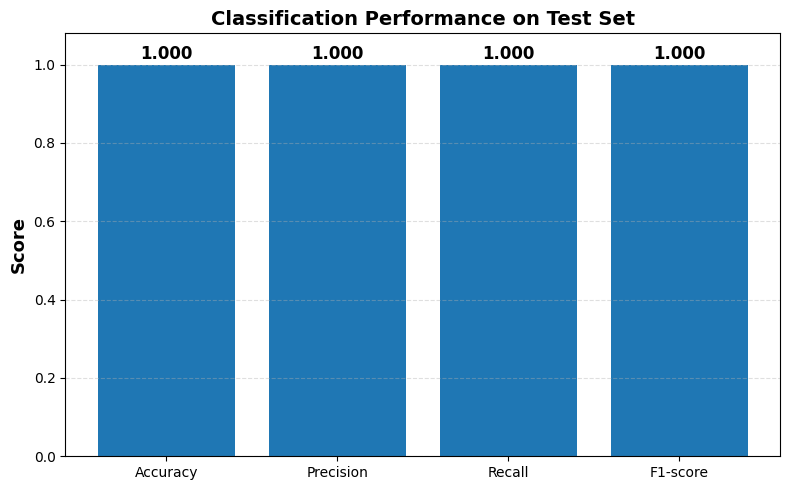

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

acc = accuracy_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
pre = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

metrics = [acc, pre, rec, f1]
names = ["Accuracy", "Precision", "Recall", "F1-score"]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, metrics)

for bar, value in zip(bars, metrics):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.015,
        f"{value:.3f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.ylim(0, 1.08)
plt.ylabel("Score", fontsize=13, fontweight="bold")
plt.title("Classification Performance on Test Set", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

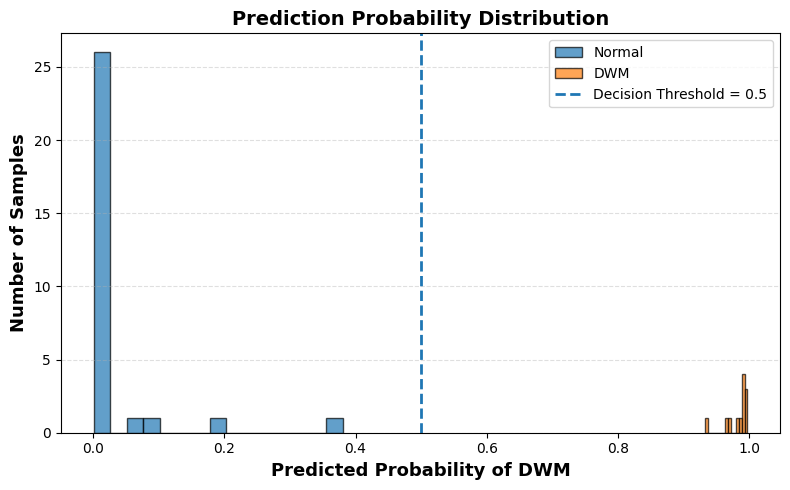

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    y_score[y_true == 0],
    bins=15,
    alpha=0.7,
    label="Normal",
    edgecolor="black"
)

plt.hist(
    y_score[y_true == 1],
    bins=15,
    alpha=0.7,
    label="DWM",
    edgecolor="black"
)

plt.axvline(0.5, linestyle="--", linewidth=2, label="Decision Threshold = 0.5")

plt.xlabel("Predicted Probability of DWM", fontsize=13, fontweight="bold")
plt.ylabel("Number of Samples", fontsize=13, fontweight="bold")
plt.title("Prediction Probability Distribution", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()